# Desafio do Cenário Atual 

As queimadas no Brasil destroem ecossistemas vitais nos biomas da Amazônia, Cerrado e Pantanal, entre outros, anualmente. O monitoramento reativo tradicional, apenas apagar o fogo após o início, gera custos econômicos massivos e perdas irreparáveis de biodiversidade. 
Conectando com a temática de Indústria Espacial, os fluxos de dados brutos gerados por satélites de sensoriamento remoto, como o GOES-16 e os sistemas do INPE, geram terabytes diários. O grande gargalo das instituições não é a falta de dados, mas sim, a capacidade de converter esses dados brutos de satélite em inteligência preventiva e preditiva. 

## Cenário Proposto & A Solução FIREDetect 

O FIREDetect é uma solução inteligente de análise preditiva baseada em Data Science que unifica dados históricos de múltiplos satélites orbitais para prever o Risco de Fogo (risco_fogo) e a intensidade de queima expressa pelo Fire Radiative Power (frp). Em vez de apenas registrar onde o fogo está, o sistema utiliza algoritmos de Machine Learning para prever o risco e a severidade dos focos com base em variáveis climáticas cruciais coletadas via satélite (como dias sem chuva e precipitação). 

### Alinhamento com as ODS (Objetivos de Desenvolvimento Sustentável da ONU) 

•	ODS 13 (Ação Contra a Mudança Global do Clima): Mitigação direta das emissões de gases estufa provocadas por incêndios florestais em larga escala. 
•	ODS 15 (Vida Terrestre): Proteção ativa da fauna, flora e preservação da integridade dos biomas brasileiros contra degradação ambiental. 

### Público-Alvo e Stakeholders 

•	Órgãos Ambientais e de Fiscalização: ICMBio, IBAMA e Secretarias Estaduais de Meio Ambiente que precisam otimizar e direcionar equipes de campo. 
•	Defesa Civil e Corpos de Bombeiros: Para o planejamento tático de alocação de brigadas de incêndio antes que as crises fujam do controle. 


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurações visuais dos gráficos á serem plotados
sns.set_theme(style="darkgrid")
#plt.rcParams['figure.figsize'] = (12, 6)

Pipeline de Ingestão de Dados em Larga Escala, utilizando técnicas avançadas de Web Scraping, por meio da biblioteca BeautifulSoup, para minerar o diretório de dados abertos do INPE. Visando a máxima precisão do modelo preditivo, o pipeline foi desenhado para realizar a ingestão volumétrica integral (sem limitação ou corte de registros) dos dois meses mais recentes publicados. Os dados brutos são unificados em memória via biblioteca Pandas através de concatenação estruturada. Esse processo consolida centenas de milhares de registros geoespaciais reais, fornecendo uma base de dados robusta contendo distribuições exatas por estados, municípios e biomas para o aprendizado do algoritmo.

In [3]:
URL_INPE = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil/"

# Raspagem da página com BeautifulSoup para encontrar os arquivos
print("1. Buscando a lista completa de arquivos no servidor do INPE...")
resposta = requests.get(URL_INPE)
soup = BeautifulSoup(resposta.text, 'html.parser')

1. Buscando a lista completa de arquivos no servidor do INPE...


In [4]:
# Encontra todos os links que terminam com .csv
todos_links = [link.get('href') for link in soup.find_all('a') if link.get('href', '').endswith('.csv')]
todos_links.sort()

# Seleciona os dois meses mais recentes
arquivo_1 = todos_links[-1]
arquivo_2 = todos_links[-2]

print(f"-> Arquivos localizados para download: {arquivo_1} e {arquivo_2}")

-> Arquivos localizados para download: focos_mensal_br_202606.csv e focos_mensal_br_202605.csv


In [5]:
# Carrega os dois arquivos CSV COMPLETOS
print("\n2. Baixando e carregando as bases de dados completas no Pandas...")
df1 = pd.read_csv(URL_INPE + arquivo_1)
df2 = pd.read_csv(URL_INPE + arquivo_2)


2. Baixando e carregando as bases de dados completas no Pandas...


In [6]:
# Unificar(concatenar) os dois meses em um único DataFrame consolidado
df_total = pd.concat([df1, df2], ignore_index=True)
print(f"✓ Sucesso! Total de 100% dos registros unificados: {len(df_total)} linhas processadas.")

✓ Sucesso! Total de 100% dos registros unificados: 114327 linhas processadas.


In [7]:
# Visualizar uma amostra dos dados após a unificação
df_total.head(2)

,id,lat,lon,data_hora_gmt,satelite,municipio,estado,pais,municipio_id,estado_id,pais_id,numero_dias_sem_chuva,precipitacao,risco_fogo,bioma,frp
0,873477fd-5b56-3537-a5df-c3f8baa70449,-15.5945,-49.8292,2026-06-01 00:00:00,GOES-19,ITAPURANGA,GOIÁS,Brasil,5211206,52,33,9,0.0,1.00,Cerrado,55.1
1,59ed7aaf-198e-30f2-9b9f-187e0bac82ff,-11.6286,-52.5702,2026-06-01 00:00:00,GOES-19,SÃO FÉLIX DO ARAGUAIA,MATO GROSSO,Brasil,5107859,51,33,2,0.0,0.54,Amazônia,36.0


In [8]:
# Padroniza as colunas e exibe o ranking real
df_total.columns = [col.lower() for col in df_total.columns]

print("\n3. Ranking Real: Distribuição acumulada de focos por Estado (Top 5):")
if 'estado' in df_total.columns:
    print(df_total['estado'].value_counts().head(5))

print("\n4. Ranking Real: Distribuição acumulada de focos por Bioma:")
if 'bioma' in df_total.columns:
    print(df_total['bioma'].value_counts())


3. Ranking Real: Distribuição acumulada de focos por Estado (Top 5):
estado
MATO GROSSO     31705
TOCANTINS       27200
BAHIA           12727
MARANHÃO         9281
MINAS GERAIS     5402
Name: count, dtype: int64

4. Ranking Real: Distribuição acumulada de focos por Bioma:
bioma
Cerrado           70957
Amazônia          28046
Mata Atlântica     6842
Caatinga           6268
Pantanal           1579
Pampa               635
Name: count, dtype: int64


In [9]:
# Checando o dataset e a tipagem dios dados
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 114327 entries, 0 to 114326
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     114327 non-null  str    
 1   lat                    114327 non-null  float64
 2   lon                    114327 non-null  float64
 3   data_hora_gmt          114327 non-null  str    
 4   satelite               114327 non-null  str    
 5   municipio              114327 non-null  str    
 6   estado                 114327 non-null  str    
 7   pais                   114327 non-null  str    
 8   municipio_id           114327 non-null  int64  
 9   estado_id              114327 non-null  int64  
 10  pais_id                114327 non-null  int64  
 11  numero_dias_sem_chuva  114327 non-null  int64  
 12  precipitacao           114327 non-null  float64
 13  risco_fogo             114327 non-null  float64
 14  bioma                  114327 non-null  str    

### **Tratamento de Dados Faltantes** (Missing Values)

In [10]:
# Verificar dados faltantes
print(f"\n🔍 Dados faltantes por coluna:\n{df_total.isnull().sum()}")


🔍 Dados faltantes por coluna:
id                          0
lat                         0
lon                         0
data_hora_gmt               0
satelite                    0
municipio                   0
estado                      0
pais                        0
municipio_id                0
estado_id                   0
pais_id                     0
numero_dias_sem_chuva       0
precipitacao                0
risco_fogo                  0
bioma                       0
frp                      1983
dtype: int64


Durante a etapa de análise exploratória da base de dados extraidas do INPE, foi identificada a ausência de registros (1.897 dados nulos), exclusivamente na métrica FRP (Fire Radiative Power). Essa inconsistência ocorre devido à heterogeneidade da constelação de satélites parceiros, onde sensores de órbitas distintas podem não possuir a tecnologia termal necessária para a quantificação de megawatts radiantes. 

Para mitigar o problema e evitar vieses no treinamento do algoritmo de Machine Learning, a arquitetura do FirePredict aplicou a técnica de imputação por valor constante (.fillna(0)), neutralizando o impacto estatístico das ausências sem a necessidade de descartar valiosas coordenadas geográficas de ocorrência do foco

## <center> **Analise Exploratoria** </center>

In [11]:
# Estatísticas básicas
print("\n📈 Estatísticas descritivas:")
display(df_total.describe().T)


📈 Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
lat,114327.0,-1.221115e+01,4.555025e+00,-3.364092e+01,-1.401541e+01,-1.151179e+01,-9.615195e+00,4.955840e+00
lon,114327.0,-4.980034e+01,5.466560e+00,-7.355801e+01,-5.374250e+01,-4.868604e+01,-4.605224e+01,-3.489475e+01
municipio_id,114327.0,3.244243e+06,1.479218e+06,1.100015e+06,1.717909e+06,2.917359e+06,5.103858e+06,5.300108e+06
estado_id,114327.0,3.233193e+01,1.480686e+01,1.100000e+01,1.700000e+01,2.900000e+01,5.100000e+01,5.300000e+01
pais_id,114327.0,3.300000e+01,0.000000e+00,3.300000e+01,3.300000e+01,3.300000e+01,3.300000e+01,3.300000e+01
numero_dias_sem_chuva,114327.0,8.102749e+00,6.776747e+01,-9.990000e+02,6.000000e+00,1.000000e+01,1.800000e+01,6.200000e+01
precipitacao,114327.0,1.421779e-01,1.071017e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.938000e+01
risco_fogo,114327.0,-6.607315e+00,8.486628e+01,-9.990000e+02,3.800000e-01,7.100000e-01,9.600000e-01,1.000000e+00
frp,112344.0,3.224920e+01,6.779825e+01,0.000000e+00,3.500000e+00,7.900000e+00,3.082500e+01,1.678600e+03



📍 Focos de queimada por estado:
estado
MATO GROSSO           31705
TOCANTINS             27200
BAHIA                 12727
MARANHÃO               9281
MINAS GERAIS           5402
PARÁ                   5087
GOIÁS                  4884
PIAUÍ                  4772
SÃO PAULO              2565
MATO GROSSO DO SUL     2455
Name: count, dtype: int64


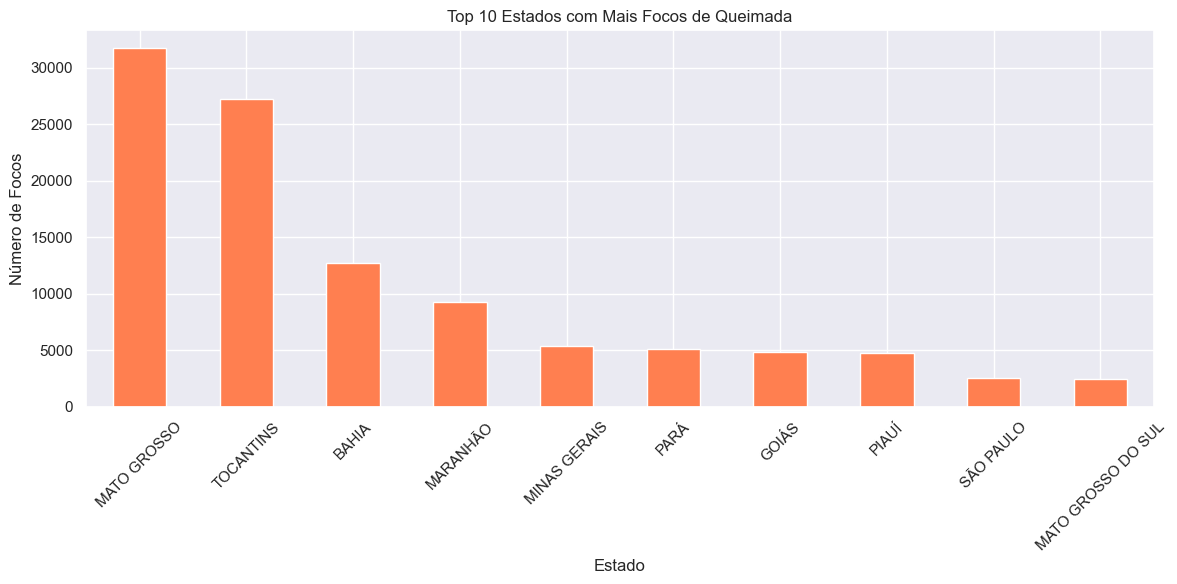

In [12]:
# Distribuição de queimadas por estado (se houver coluna estado)
if 'estado' in df_total.columns:
    print("\n📍 Focos de queimada por estado:")
    focos_estado = df_total['estado'].value_counts().head(10)
    print(focos_estado)
    
    plt.figure(figsize=(12,6))
    focos_estado.plot(kind='bar', color='coral')
    plt.title('Top 10 Estados com Mais Focos de Queimada')
    plt.xlabel('Estado')
    plt.ylabel('Número de Focos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('focos_por_estado.png', dpi=150)
    plt.show()

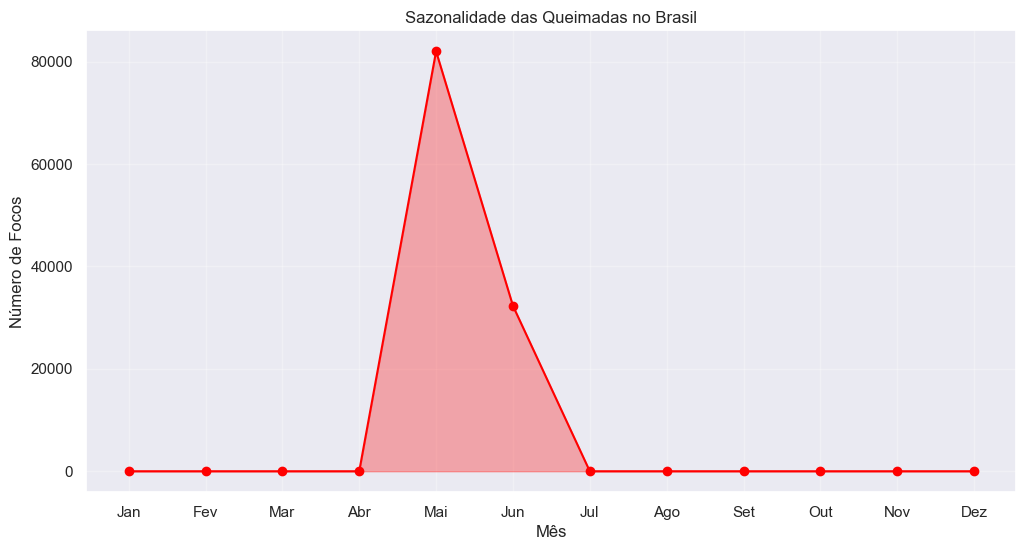

In [13]:
# Análise temporal - Sazonalidade das queimadas
if 'data_hora_gmt' in df_total.columns:
    df_total['data_hora_gmt'] = pd.to_datetime(df_total['data_hora_gmt'])
    df_total['mes'] = df_total['data_hora_gmt'].dt.month
    df_total['ano'] = df_total['data_hora_gmt'].dt.year
    focos_por_mes = df_total.groupby('mes').size().reindex(range(1, 13), fill_value=0)
    plt.figure(figsize=(12,6))
    meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
    plt.plot(focos_por_mes.index, focos_por_mes.values, marker='o', color='red')
    plt.fill_between(focos_por_mes.index, focos_por_mes.values, alpha=0.3, color='red')
    plt.xticks(range(1,13), meses)
    plt.title('Sazonalidade das Queimadas no Brasil')
    plt.xlabel('Mês')
    plt.ylabel('Número de Focos')
    plt.grid(True, alpha=0.3)
    plt.savefig('sazonalidade.png', dpi=150)
    plt.show()


🌳 Focos por bioma:


bioma
Cerrado           70957
Amazônia          28046
Mata Atlântica     6842
Caatinga           6268
Pantanal           1579
Pampa               635
Name: count, dtype: int64

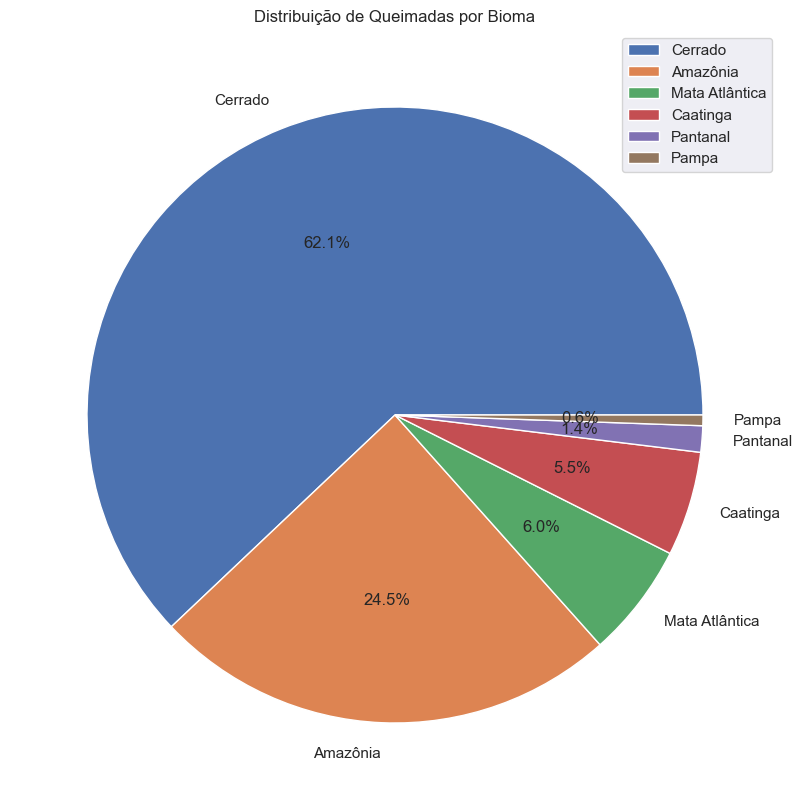

In [14]:
# Distribuição por bioma
if 'bioma' in df_total.columns:
    print("\n🌳 Focos por bioma:")
    focos_bioma = df_total['bioma'].value_counts()
    display(focos_bioma)
    plt.figure(figsize=(12,10))
    plt.pie(focos_bioma, labels=focos_bioma.index, autopct='%1.1f%%')
    plt.title('Distribuição de Queimadas por Bioma')
    plt.legend(focos_bioma.index, loc='upper right')
    plt.savefig('focos_por_bioma.png', dpi=150)
    plt.show()

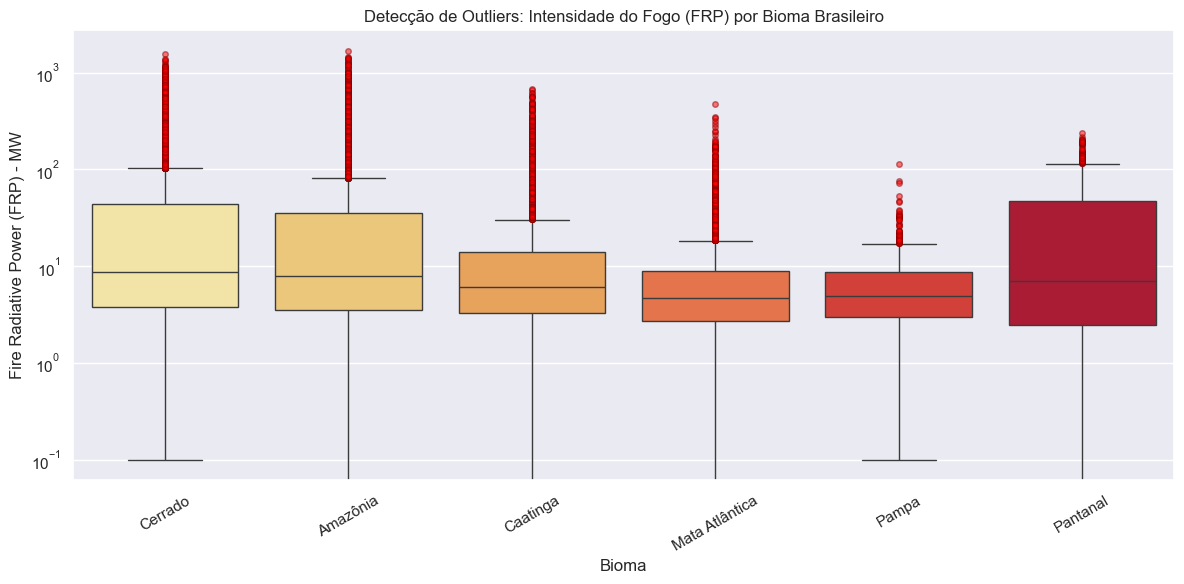

In [15]:
# GRÁFICO 1: ANÁLISE DE OUTLIERS VIA BOXPLOT (FRP por Bioma)
plt.figure(figsize=(12,6))
sns.boxplot(
    x='bioma', 
    y='frp', 
    data=df_total, 
    palette='YlOrRd', 
    fliersize=4,
    flierprops={"markerfacecolor": "red", "markeredgecolor": "darkred", "alpha": 0.5}
)
plt.title('Detecção de Outliers: Intensidade do Fogo (FRP) por Bioma Brasileiro')
plt.xlabel('Bioma')
plt.ylabel('Fire Radiative Power (FRP) - MW')
plt.xticks(rotation=30)
plt.yscale('log') # Escala logarítmica aplicada porque a energia do fogo varia massivamente
plt.tight_layout()
plt.savefig('01_outliers_boxplot_bioma.png', dpi=300)
plt.show()

<Figure size 1600x1200 with 0 Axes>

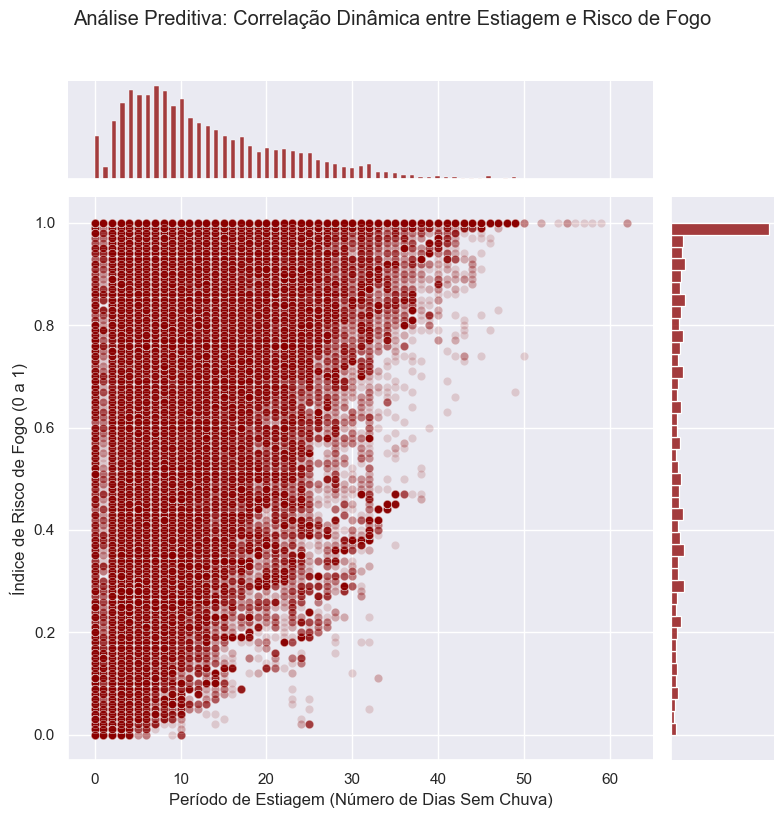

In [16]:
# GRÁFICO 2: RISCO DE FOGO VS DIAS SEM CHUVA 
df_filtrado = df_total[
    (df_total['risco_fogo'] >= 0) & 
    (df_total['risco_fogo'] <= 1) & 
    (df_total['numero_dias_sem_chuva'] >= 0) &
    (df_total['numero_dias_sem_chuva'] < 90) # Filtra estiagens fora da realidade do bimestre
].dropna(subset=['risco_fogo', 'numero_dias_sem_chuva'])

# Jointplot com os dados limpos
plt.figure(figsize=(16, 12))
g = sns.jointplot(
    x='numero_dias_sem_chuva', 
    y='risco_fogo', 
    data=df_filtrado,
    kind='scatter', 
    color='darkred',      # Cor voltada ao tema de queimadas
    alpha=0.15,          # Opacidade baixa para enxergar onde há maior densidade de pontos
    height=8
)

# Ajustes de títulos e rótulos limpos
g.fig.suptitle('Análise Preditiva: Correlação Dinâmica entre Estiagem e Risco de Fogo', y=1.02)
g.set_axis_labels('Período de Estiagem (Número de Dias Sem Chuva)', 'Índice de Risco de Fogo (0 a 1)')

plt.tight_layout()
plt.savefig('02_eda_dispersao_risco_corrigido.png', dpi=300)
plt.show();

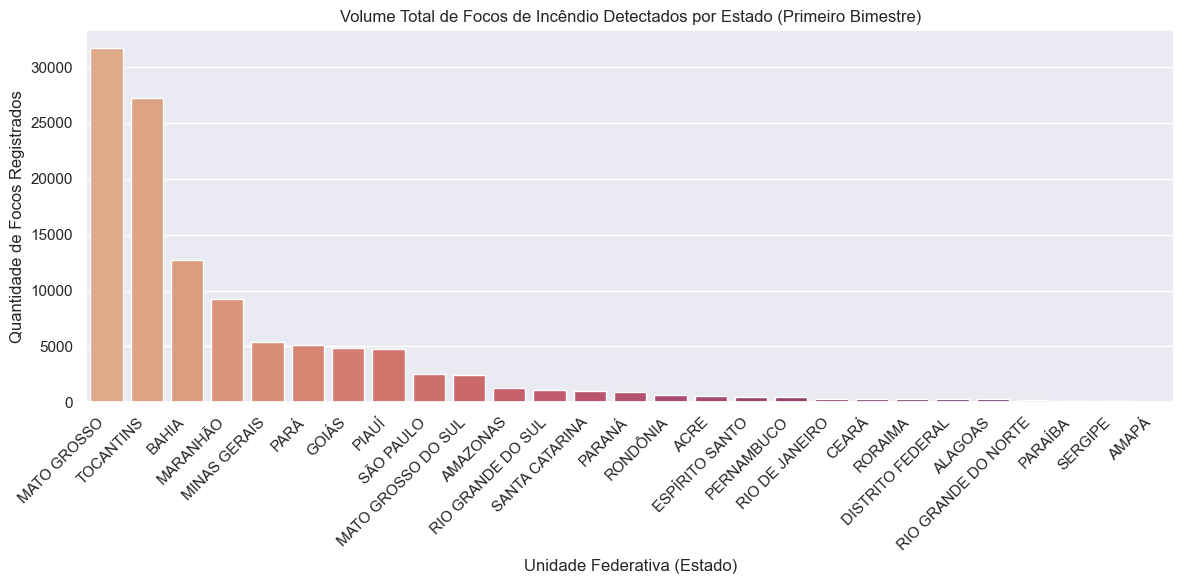

In [17]:
# GRÁFICO 4: VOLUME ANUAL DE FOCOS POR ESTADO (Gráfico de Barras Ordenado)
plt.figure(figsize=(12, 6))
order_estados = df_total['estado'].value_counts().index

sns.countplot(
    x='estado', 
    data=df_total, 
    order=order_estados, 
    palette='flare'
)
plt.title('Volume Total de Focos de Incêndio Detectados por Estado (Primeiro Bimestre)')
plt.xlabel('Unidade Federativa (Estado)')
plt.ylabel('Quantidade de Focos Registrados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_eda_focos_por_estado.png', dpi=300)
plt.show()

### <center> **Tratamento de Valores Ausentes** </center>

In [18]:
# Criar uma cópia de trabalho segura
df =  df_total.copy()

# É comum dados orbitais virem com flags de erro como -999.0 para risco de fogo ou nulos
df['risco_fogo'] = df['risco_fogo'].replace(-999.0, np.nan)
df['frp'] = df['frp'].replace(-999.0, np.nan)

In [19]:
# Preenchimento inteligente por mediana para evitar viés
df['risco_fogo'] = df['risco_fogo'].fillna(df['risco_fogo'].median())
df['frp'] = df['frp'].fillna(df['frp'].median())
df['precipitacao'] = df['precipitacao'].fillna(0.0) # Falta de registro de chuva assume-se 0

### <center> **Tratamento de Dados Temporal** </center>

In [20]:
# Conversão e Extração Temporal
df['data_hora_gmt'] = pd.to_datetime(df['data_hora_gmt'])
df['dia_do_ano'] = df['data_hora_gmt'].dt.dayofyear
df['dia_da_semana'] = df['data_hora_gmt'].dt.dayofweek
df['hora_do_registro'] = df['data_hora_gmt'].dt.hour

### <center> **Encoding de Variáveis Categóricas** </center>

In [21]:
# Encoding de Variáveis Categóricas (Transformação de Texto em Número)
# Satélites, Municípios, Estados e Biomas mapeados estatisticamente
encoders = {}
categorical_cols = ['satelite', 'estado', 'bioma', 'municipio']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le # Salvando o encoder caso precise reverter no futuro

In [22]:
# Verificação do dataset após tratamentos e encodings
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114327 entries, 0 to 114326
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     114327 non-null  str           
 1   lat                    114327 non-null  float64       
 2   lon                    114327 non-null  float64       
 3   data_hora_gmt          114327 non-null  datetime64[us]
 4   satelite               114327 non-null  str           
 5   municipio              114327 non-null  str           
 6   estado                 114327 non-null  str           
 7   pais                   114327 non-null  str           
 8   municipio_id           114327 non-null  int64         
 9   estado_id              114327 non-null  int64         
 10  pais_id                114327 non-null  int64         
 11  numero_dias_sem_chuva  114327 non-null  int64         
 12  precipitacao           114327 non-null  float64       


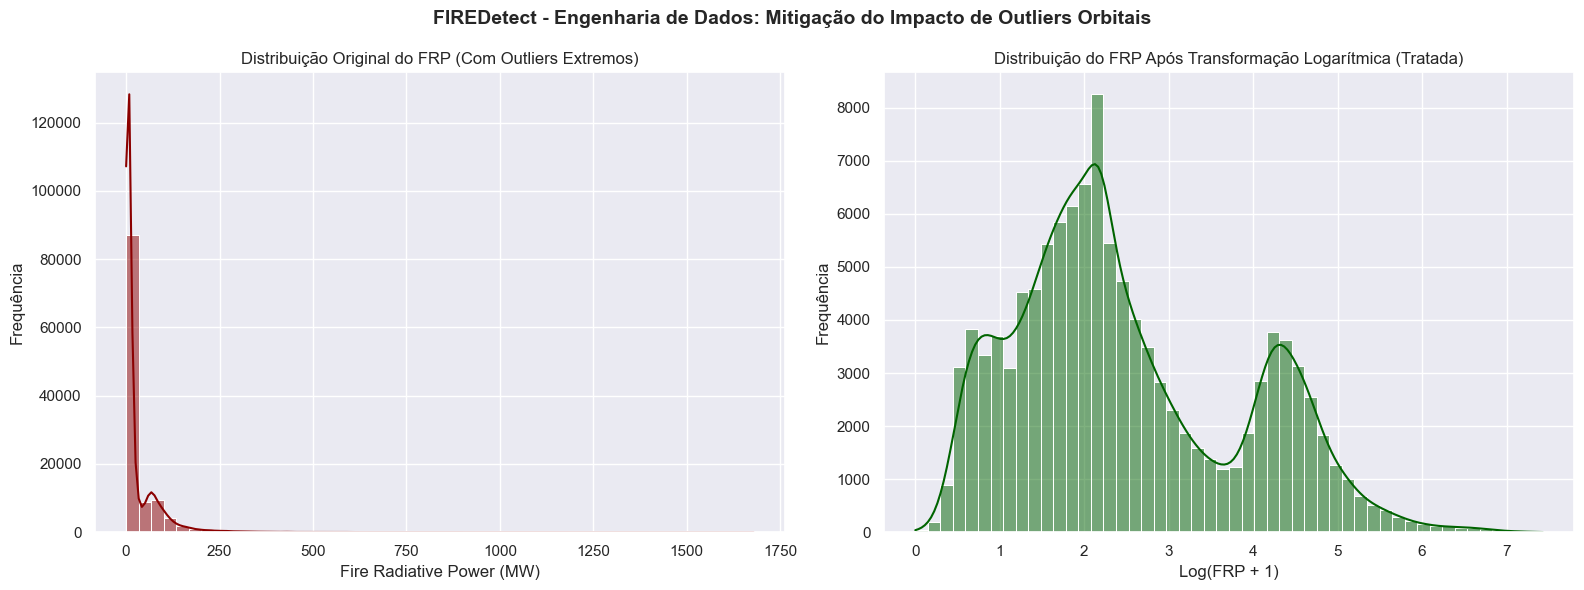

In [23]:
df_tratado = df.copy()

# Aplicar transformação logarítmica (log1p) no FRP para reduzir o impacto dos outliers
df_tratado['frp_log'] = np.log1p(df_tratado['frp'])

# Plotar o painel comparativo Antes vs Depois 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Antes (Distribuição com cauda longa pesada devido aos outliers)
sns.histplot(df['frp'].dropna(), bins=50, kde=True, color='darkred', ax=axes[0])
axes[0].set_title('Distribuição Original do FRP (Com Outliers Extremos)', fontsize=12)
axes[0].set_xlabel('Fire Radiative Power (MW)')
axes[0].set_ylabel('Frequência')

# Gráfico Depois (Distribuição Normalizada/Tratada para o Modelo)
sns.histplot(df_tratado['frp_log'], bins=50, kde=True, color='darkgreen', ax=axes[1])
axes[1].set_title('Distribuição do FRP Após Transformação Logarítmica (Tratada)', fontsize=12)
axes[1].set_xlabel('Log(FRP + 1)')
axes[1].set_ylabel('Frequência')

plt.suptitle('FIREDetect - Engenharia de Dados: Mitigação do Impacto de Outliers Orbitais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_tratamento_outliers_antes_depois.png', dpi=300)
plt.show()

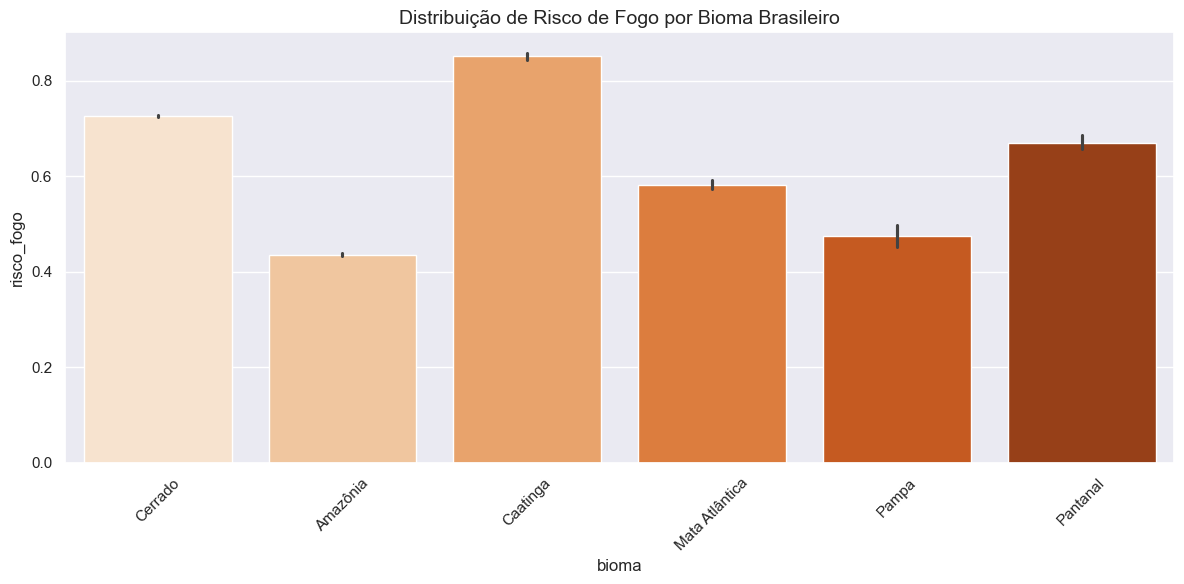

In [24]:
# Insight : Distribuição do Risco de Fogo por Bioma
plt.figure(figsize=(12, 6))
sns.barplot(x='bioma', y='risco_fogo', data=df_tratado, palette='Oranges')
plt.title('Distribuição de Risco de Fogo por Bioma Brasileiro', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_risco_por_bioma.png')
plt.show()

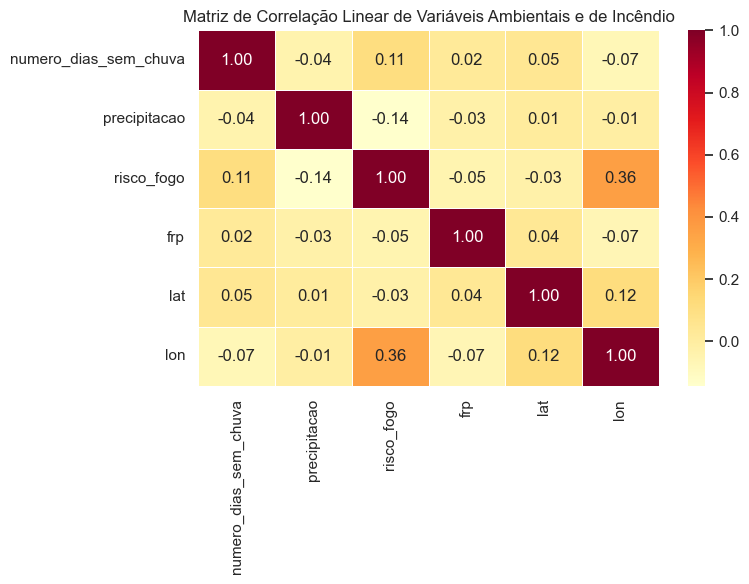

In [25]:
# Insight : Correlação Climática das Variáveis Orbitais
plt.figure(figsize=(8, 6))
correlation_matrix = df_tratado[['numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'frp', 'lat', 'lon']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Linear de Variáveis Ambientais e de Incêndio', fontsize=12)
plt.tight_layout()
plt.savefig('eda_matriz_correlacao.png')
plt.show()

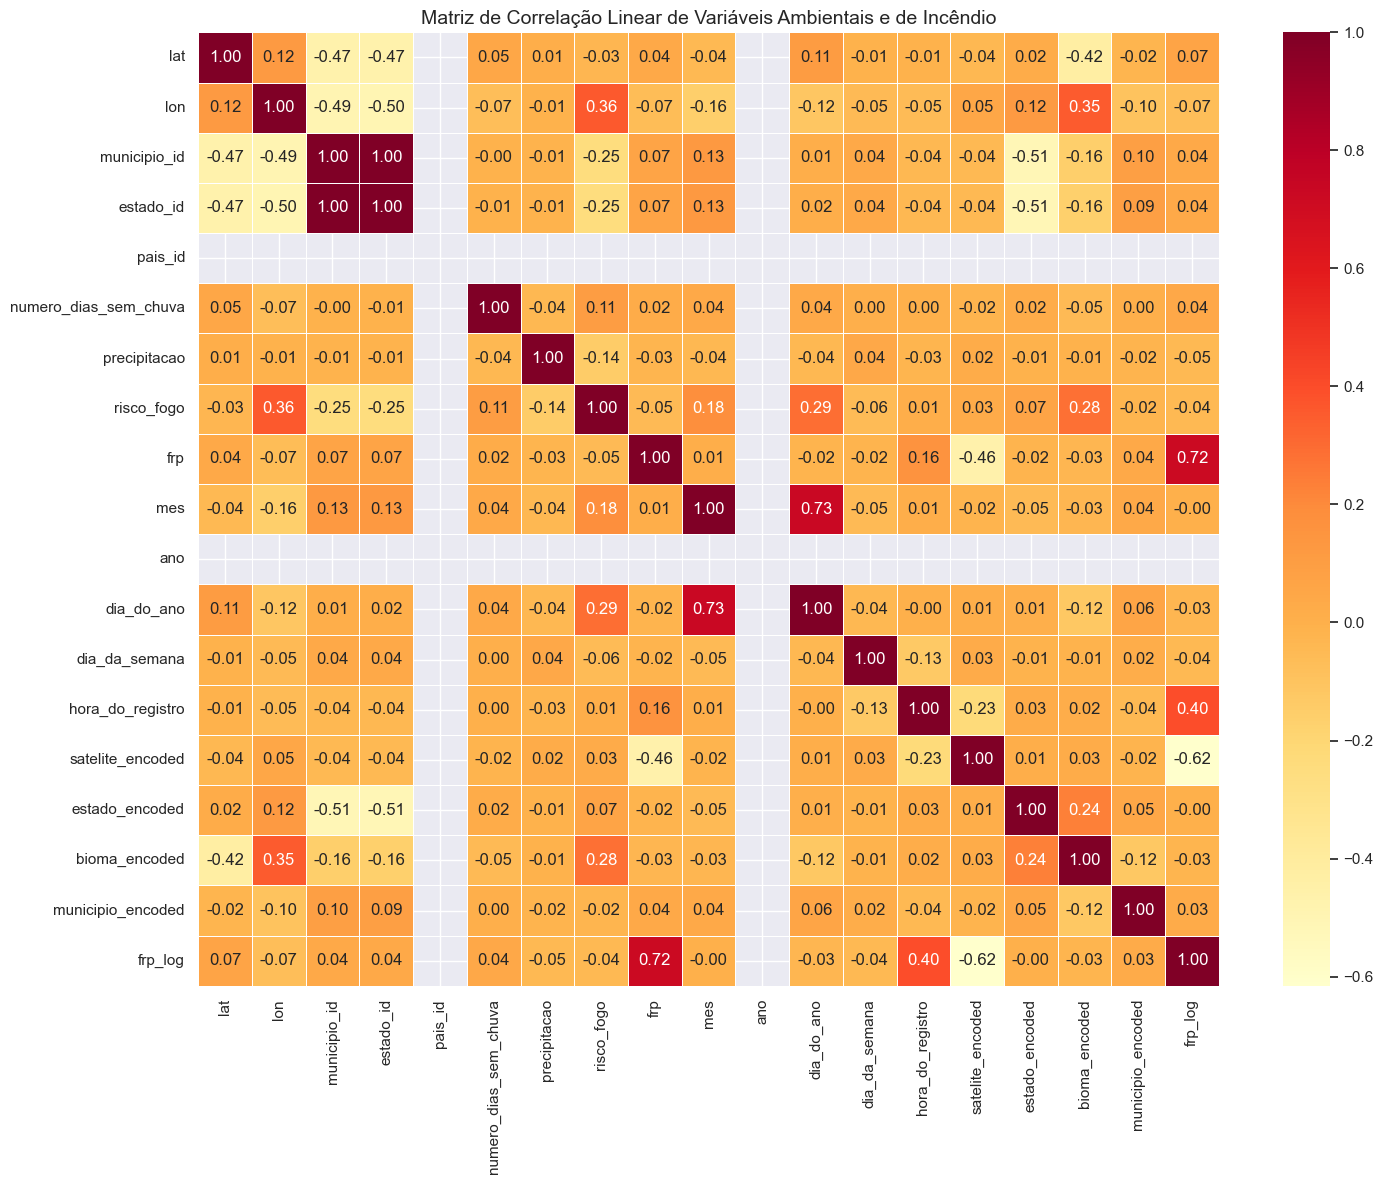

In [26]:
# Insight : Correlação Climática das Variáveis Orbitais
plt.figure(figsize=(15, 12))
correlation_matrix = df_tratado.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Linear de Variáveis Ambientais e de Incêndio', fontsize=14)
plt.tight_layout()
plt.savefig('eda_matriz_correlacao.png')
plt.show()

# <center> DIVISÃO DA BASE E ARQUITETURA DE MACHINE LEARNING </center> 

### Objetivo do FIREDetect: **Prever o Risco de Fogo com base nas condições observadas**

In [27]:
# Variáveis preditoras (X) 
X = df_tratado.drop(columns=[
    'ano',
    'pais_id',
    'risco_fogo',
    'pais',
    'estado_id',                
    'satelite_encoded',         
    'mes',
    'id',
    'data_hora_gmt', 
    'satelite', 
    'estado', 
    'bioma', 
    'municipio', 
    'dia_da_semana',
    'estado_encoded', 
    'frp',
    'hora_do_registro',
    'frp_log',
    'municipio_id'
    ]) 

# Variável alvo (y)
y = df_tratado['risco_fogo']

# Divisão Padrão Ouro de Mercado: 80% Treino e 20% Teste com reprodutibilidade (random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"-> Conjunto de Treinamento: {X_train.shape[0]} amostras.")
print(f"-> Conjunto de Teste/Validação: {X_test.shape[0]} amostras.")

-> Conjunto de Treinamento: 91461 amostras.
-> Conjunto de Teste/Validação: 22866 amostras.


In [28]:
# VERIFICAÇÃO DO DATASET APÓS TRATAMENTOS E ENCODINGS
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 114327 entries, 0 to 114326
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   lat                    114327 non-null  float64
 1   lon                    114327 non-null  float64
 2   numero_dias_sem_chuva  114327 non-null  int64  
 3   precipitacao           114327 non-null  float64
 4   dia_do_ano             114327 non-null  int32  
 5   bioma_encoded          114327 non-null  int64  
 6   municipio_encoded      114327 non-null  int64  
dtypes: float64(3), int32(1), int64(3)
memory usage: 5.7 MB


### **TREINAMENTO E COMPARAÇÃO DE MODELOS PREDITIVOS**

In [29]:
# MODELO 1: RANDOM FOREST REGRESSOR 
print("Treinando Modelo 1: Random Forest Regressor (Ensemble Learning)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

Treinando Modelo 1: Random Forest Regressor (Ensemble Learning)...


In [30]:
# MODELO 2: XGBOOST REGRESSOR
print("Treinando Modelo 2: XGBoost Regressor (Gradient Boosting de Alta Performance)...")
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

Treinando Modelo 2: XGBoost Regressor (Gradient Boosting de Alta Performance)...


In [31]:
# AVALIAÇÃO DE DESEMPENHO
def calcular_metricas(y_true, y_pred, nome_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nMÉTRICAS: Performance do {nome_modelo}:")
    print(f" -> Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f" -> Mean Absolute Error (MAE): {mae:.4f}")
    print(f" -> Coeficiente de Determinação (R² Score): {r2:.4f}")
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

metrics_rf = calcular_metricas(y_test, rf_preds, "Random Forest")
metrics_xgb = calcular_metricas(y_test, xgb_preds, "XGBoost")


MÉTRICAS: Performance do Random Forest:
 -> Root Mean Squared Error (RMSE): 0.1173
 -> Mean Absolute Error (MAE): 0.0753
 -> Coeficiente de Determinação (R² Score): 0.8538

MÉTRICAS: Performance do XGBoost:
 -> Root Mean Squared Error (RMSE): 0.1366
 -> Mean Absolute Error (MAE): 0.0955
 -> Coeficiente de Determinação (R² Score): 0.8018


### <center> **Feature Selection** </center>


-> O modelo Random Forest apresentou melhor desempenho geral com base no R² Score.

--- Relevância das Variáveis (Melhores para Pior) ---
lon                      0.342461
lat                      0.308854
dia_do_ano               0.176970
numero_dias_sem_chuva    0.097083
municipio_encoded        0.036544
bioma_encoded            0.019161
precipitacao             0.018928
dtype: float64 




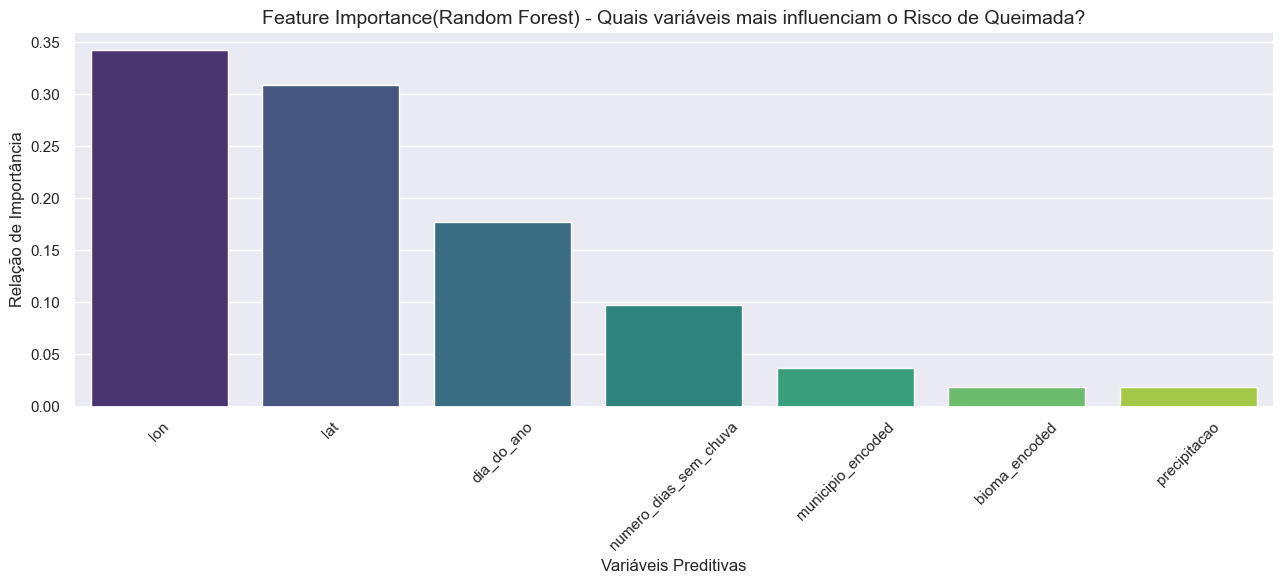

In [32]:
def comparar_modelos(metrics_rf, metrics_xgb):
    if metrics_rf['R2'] < metrics_xgb['R2']:
        importancia = pd.Series(xgb_model.feature_importances_, index=X.columns)
        importancia = importancia.sort_values(ascending=False)
        print("\n-> O modelo XGBoost apresentou melhor desempenho geral com base no R² Score.")
        print("\n--- Relevância das Variáveis (Melhores para Pior) ---")
        print(importancia,'\n\n')
        plt.figure(figsize=(13, 6))
        sns.barplot(x=importancia.index, y=importancia.values, palette='viridis')
        plt.title('Feature Importance(XGBoost) - Quais variáveis mais influenciam o Risco de Queimada?', fontsize=14)
        plt.xticks(rotation=45)
        plt.ylabel('Importância Relativa')
        plt.xlabel('Variáveis Preditivas')
        plt.tight_layout()
        plt.savefig('ml_importancia_atributos.png')
        plt.show()
    else:
        importancia = pd.Series(rf_model.feature_importances_, index=X.columns)
        importancia = importancia.sort_values(ascending=False)
        print("\n-> O modelo Random Forest apresentou melhor desempenho geral com base no R² Score.")
        print("\n--- Relevância das Variáveis (Melhores para Pior) ---")
        print(importancia,'\n\n')
        plt.figure(figsize=(13, 6))
        sns.barplot(x=importancia.index, y=importancia.values, palette='viridis')
        plt.title('Feature Importance(Random Forest) - Quais variáveis mais influenciam o Risco de Queimada?', fontsize=14)
        plt.xticks(rotation=45)
        plt.ylabel('Relação de Importância')
        plt.xlabel('Variáveis Preditivas')
        plt.tight_layout()
        plt.savefig('ml_importancia_atributos.png')
        plt.show()

comparar_modelos(metrics_rf, metrics_xgb)

# <center> **Visualização dos Resultados e Erros do Modelo** </center>

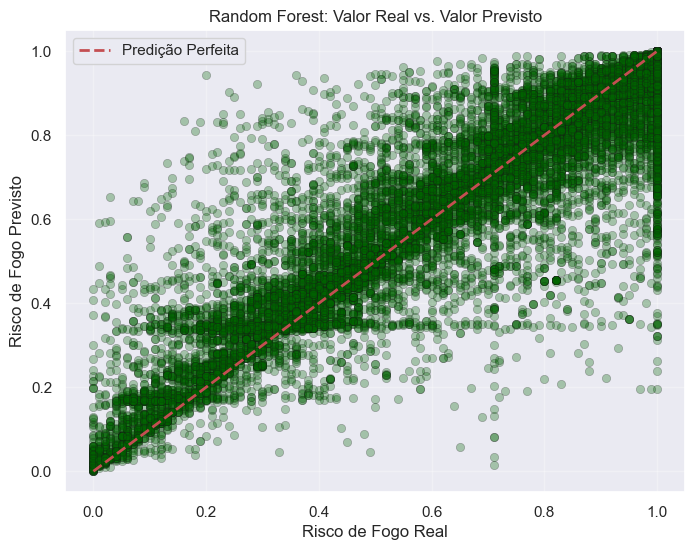

In [33]:
# Gráfico de Dispersão: Valor Real vs. Predito (Random Forest)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.3, color='darkgreen', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predição Perfeita')
plt.xlabel('Risco de Fogo Real')
plt.ylabel('Risco de Fogo Previsto')
plt.title('Random Forest: Valor Real vs. Valor Previsto')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('06_rf_real_vs_predito.png', dpi=300)
plt.show()

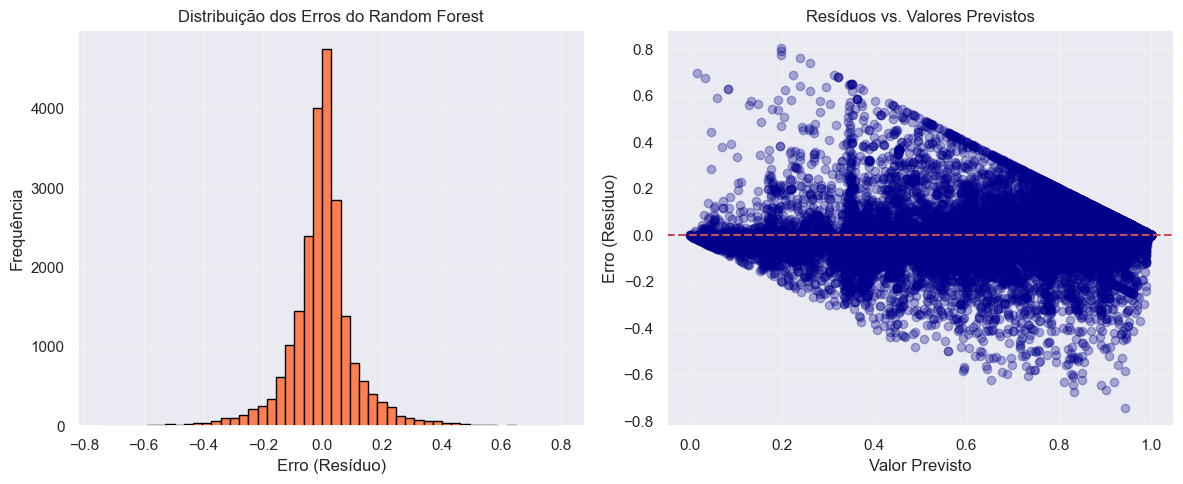

In [34]:
# Análise de Resíduos (Erros)
residuos = y_test - rf_preds

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(residuos, bins=50, color='coral', edgecolor='black')
plt.xlabel('Erro (Resíduo)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Erros do Random Forest')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(rf_preds, residuos, alpha=0.3, color='darkblue')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valor Previsto')
plt.ylabel('Erro (Resíduo)')
plt.title('Resíduos vs. Valores Previstos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_rf_analise_residuos.png', dpi=300)
plt.show()

## <center> **SIMULAÇÃO REAL DE OPERAÇÃO (VALOR DE NEGÓCIO)** </center>

In [35]:
# Simulando um novo ponto de dados (ex: um novo foco de queimada)
novo_dado = pd.DataFrame({
    'lat': [-12.5],
    'lon': [-55.0],
    'numero_dias_sem_chuva': [15],
    'precipitacao': [0.0],
    'dia_do_ano': [180],  # Meio do ano (época de seca)
    'bioma_encoded': [0],  # Supondo 0 = Cerrado (ajuste do encoding)
    'municipio_encoded': [5000]  # Um código fictício
})

# colunas estão na mesma ordem do treinamento
novo_dado = novo_dado[X_train.columns]

# Predição
risco_previsto = rf_model.predict(novo_dado)[0]
print(f"\n=== Simulação de Predição ===\n")
print(f"Resultado: Para um novo foco de queimada, dentro das condições fornecidas, o risco de fogo previsto é: {risco_previsto*100:.2f}%")
print(f"Interpretação: Quanto mais próximo de 100% for o resultado, maior será o risco de incêndio.")


=== Simulação de Predição ===

Resultado: Para um novo foco de queimada, dentro das condições fornecidas, o risco de fogo previsto é: 60.66%
Interpretação: Quanto mais próximo de 100% for o resultado, maior será o risco de incêndio.


# <center> **Salvando o Modelo Treinado (Para uso futuro)** </center>

In [36]:
import joblib

# Salvar o modelo Random Forest (que teve o melhor desempenho)
joblib.dump(rf_model, 'modelo_firedetect_rf.pkl')
print("\nModelo Random Forest salvo como 'modelo_firedetect_rf.pkl'")

# (Opcional) Salvar o XGBoost também
joblib.dump(xgb_model, 'modelo_firedetect_xgb.pkl')
print("Modelo XGBoost salvo como 'modelo_firedetect_xgb.pkl'")


Modelo Random Forest salvo como 'modelo_firedetect_rf.pkl'
Modelo XGBoost salvo como 'modelo_firedetect_xgb.pkl'


# Projeto: FIREDetect
Transformando Dados Orbitais em Inteligência Preventiva contra Queimadas

### 1. Introdução e Contexto

A indústria espacial evoluiu de um campo de exploração científica para um pilar estratégico da economia global. Com uma projeção de atingir US$ 1 trilhão até 2034, o verdadeiro desafio atual reside na transformação de dados brutos captados por constelações de satélites em soluções aplicáveis na Terra. No Brasil, esse cenário é crítico: anualmente, queimadas devastam biomas como a Amazônia, o Cerrado e o Pantanal, gerando perdas bilionárias e danos irreversíveis à biodiversidade.

O projeto FIREDetect surge como uma resposta tecnológica a esse gargalo, unindo Data Science e Inteligência Artificial para converter os terabytes de dados orbitais do INPE em previsões acionáveis.

### 2. O Problema: Monitoramento Reativo vs. Preditivo

Atualmente, as ações de combate ao fogo são predominantemente reativas. As equipes são mobilizadas apenas após o foco ser detectado, momento em que o dano ambiental já se iniciou.

Volume de Dados: Satélites como o GOES-16 geram dados contínuos, mas as instituições carecem de ferramentas que cruzem esses dados com variáveis climáticas em tempo real para antecipar o risco.

Impacto Econômico: Estimativas indicam que a logística brasileira perde entre 3% e 5% de sua eficiência devido a rupturas causadas por eventos climáticos, incluindo incêndios que bloqueiam vias e destroem ativos.

### 3. Solução Proposta: FIREDetect

O FIREDetect é uma plataforma de análise preditiva que utiliza modelos de Machine Learning (Random Forest e XGBoost) treinados com dados históricos e atuais de sensoriamento remoto.

Previsão de Risco: O sistema calcula o índice risco_fogo (0 a 1) para cada coordenada.

Intensidade de Queima: Utiliza a métrica FRP (Fire Radiative Power) para prever a severidade do incêndio em megawatts.

Variáveis Climáticas: Integra dados de precipitação e dias sem chuva para refinar a precisão, alcançando um R² de 0.85 no modelo Random Forest.